# 02 — Construct the MD-derived Seitz table

This notebook uses only MD results plus the saved Argon scale.  It shows the raw
cavitation data, the homogeneous equation-of-state coverage used for interpolation,
the reduced-unit Seitz calculation, and its conversion to physical units.

REFPROP is deliberately not called here.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from md_Helpers import (
    ArgonLJScale, ProjectPaths, SQLiteRunDatabase,
    calculate_cavitation_seitz, cavitation_dataframe,
    query_seitz_eos_states,
)

MD_REPO = Path.home() / "MDsims"
DATA_DIRECTORY = MD_REPO / "Argon" / "data"
SCALE_PATH = DATA_DIRECTORY / "argon_lj_scale.json"
assert SCALE_PATH.exists(), "Run notebook 01 first."

scale_record = json.loads(SCALE_PATH.read_text())
scale = ArgonLJScale(
    epsilon_over_kb_K=scale_record["epsilon_over_kB_K"],
    sigma_nm=scale_record["sigma_nm"],
    mass_u=scale_record["mass_u"],
    epsilon_over_kb_uncertainty_K=scale_record["epsilon_over_kB_uncertainty_K"],
    sigma_uncertainty_nm=scale_record["sigma_uncertainty_nm"],
)
database = SQLiteRunDatabase(ProjectPaths().database)
database.initialize()
scale.summary()


{'epsilon_over_kB_K': 128.5995507884122,
 'epsilon_over_kB_uncertainty_K': 0.04210981133938457,
 'epsilon_J': 1.775508411964705e-21,
 'epsilon_eV': 0.011081851865059125,
 'sigma_nm': 0.33585470206734763,
 'sigma_uncertainty_nm': 9.749997282766784e-06,
 'mass_u': 39.948,
 'mass_kg': 6.63352146325368e-26,
 'time_ps': np.float64(2.0528732475325384),
 'pressure_bar': 468.6713819873131,
 'density_mol_L': 43.83235439561305,
 'velocity_m_s': np.float64(163.60225964804692),
 'force_N': 5.286537306268438e-12}

## Raw cavitation and EOS selections


In [2]:
CAVITATION_FILTERS = {
    "Nsteps": [500_000],
    "Phase_Separation_Status": "Separated",
}
EOS_FILTERS = {
    "Nsteps": 200_000,
    "dt": 0.002,
    "Ensemble": "NVT",
}

cavitations = cavitation_dataframe(database, **CAVITATION_FILTERS)
eos = query_seitz_eos_states(database, n_cells=45, **EOS_FILTERS)

print("Cavitation rows:", len(cavitations))
print("Cavitation temperatures:", sorted(cavitations["Therm_kT"].unique()))
print("EOS rows:", len(eos))
print("EOS temperatures:", sorted(eos["Therm_kT"].unique()))

cavitations[[
    "Run_ID", "N_Cells", "Therm_kT", "Initial_Density", "BoxLength",
    "rho_liquid", "rho_liquid_unc", "Pressure_Mean",
    "PE_Per_Particle_Mean", "PE_Per_Particle_SEM",
]]


Cavitation rows: 10
Cavitation temperatures: [np.int64(1)]
EOS rows: 54
EOS temperatures: [np.float64(0.9), np.float64(0.95), np.float64(1.0)]


,Run_ID,N_Cells,Therm_kT,Initial_Density,BoxLength,rho_liquid,rho_liquid_unc,Pressure_Mean,PE_Per_Particle_Mean,PE_Per_Particle_SEM
0,20260918190731,30,1,0.587034,56.779373,0.614951,0.000554,0.015966,-3.819599,0.000835
1,20260918191538,30,1,0.5771,57.103832,0.615146,0.000579,0.020717,-3.811893,0.000457
2,20260918192601,20,1,0.580265,37.852913,0.607078,0.001094,0.006132,-3.76585,0.001073
3,20260918192848,20,1,0.570031,38.069221,0.609103,0.001112,0.003987,-3.747754,0.001615
4,20260918193606,25,1,0.584893,47.316143,0.610226,0.000752,0.012085,-3.802296,0.000579
5,20260918194043,25,1,0.574868,47.586525,0.611451,0.000764,0.017157,-3.791897,0.001076
6,20260918194755,20,1,0.575311,37.960453,0.606019,0.001064,0.00791,-3.759177,0.001009
7,20260918195040,25,1,0.589916,47.183231,0.610687,0.000767,0.00948,-3.806204,0.000762
8,20260918195515,25,1,0.579815,47.450565,0.610595,0.000759,0.01212,-3.790444,0.0009
9,20260918200708,30,1,0.5822,56.940678,0.616457,0.000562,0.021476,-3.824864,0.000753


In [3]:
eos[[
    "Run_ID", "Therm_kT", "Density_End", "Pressure_Mean", "Pressure_SEM",
    "PE_Per_Particle_Mean", "PE_Per_Particle_SEM",
]].sort_values(["Therm_kT", "Density_End"])


,Run_ID,Therm_kT,Density_End,Pressure_Mean,Pressure_SEM,PE_Per_Particle_Mean,PE_Per_Particle_SEM
0,20260917232048,0.9,0.65,-0.14778,0.000506,-4.146735,0.000133
2,20260917233701,0.9,0.66,-0.125499,0.000483,-4.205511,0.000125
31,20260918213001,0.9,0.665,-0.111674,0.000575,-4.235128,0.000134
1,20260917233136,0.9,0.67,-0.097091,0.000575,-4.265018,0.000135
30,20260918212434,0.9,0.675,-0.081378,0.000532,-4.295676,0.00013
3,20260917234222,0.9,0.68,-0.063444,0.00058,-4.325869,0.000122
29,20260918211900,0.9,0.685,-0.044204,0.000591,-4.356393,0.000138
4,20260917234747,0.9,0.69,-0.023433,0.000594,-4.387147,0.000138
28,20260918211326,0.9,0.695,-0.000577,0.000553,-4.417721,0.000108
5,20260917235316,0.9,0.7,0.024266,0.000578,-4.448289,0.000133


## Visualize EOS coverage before interpolation


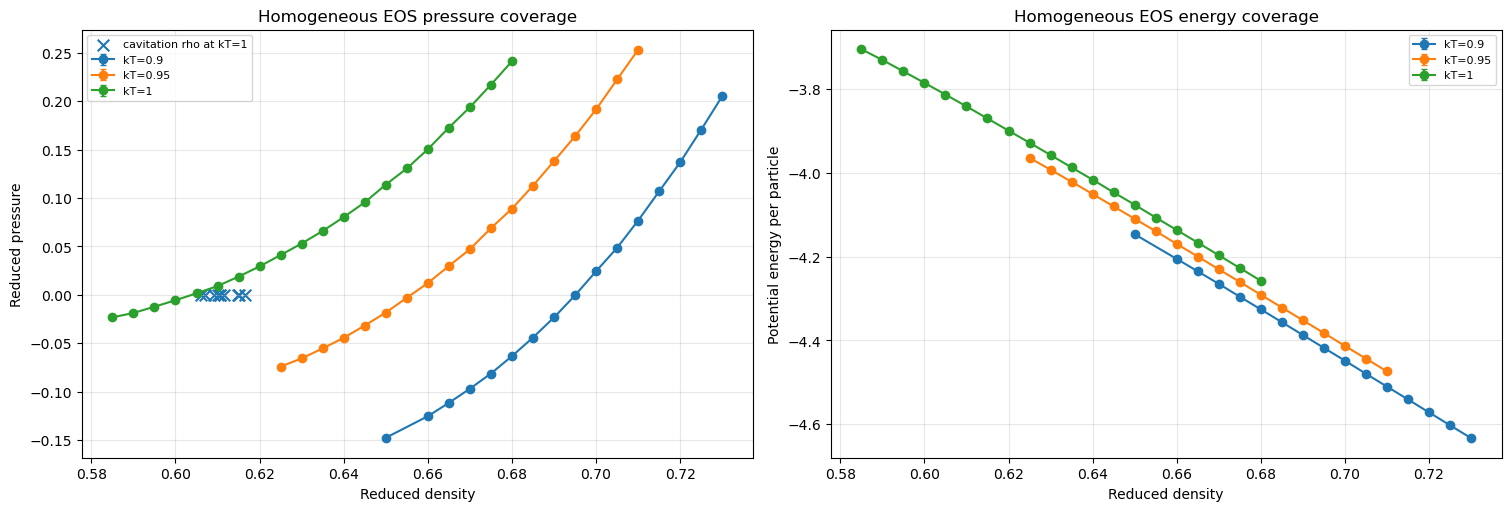

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for temperature, group in eos.groupby("Therm_kT"):
    group = group.sort_values("Density_End")
    axes[0].errorbar(group["Density_End"], group["Pressure_Mean"], yerr=group["Pressure_SEM"],
                     marker="o", capsize=2, label=f"kT={temperature:g}")
    axes[1].errorbar(group["Density_End"], group["PE_Per_Particle_Mean"],
                     yerr=group["PE_Per_Particle_SEM"], marker="o", capsize=2,
                     label=f"kT={temperature:g}")

for temperature, group in cavitations.groupby("Therm_kT"):
    axes[0].scatter(group["rho_liquid"], np.zeros(len(group)), marker="x", s=70,
                    label=f"cavitation rho at kT={temperature:g}")

axes[0].set(xlabel="Reduced density", ylabel="Reduced pressure", title="Homogeneous EOS pressure coverage")
axes[1].set(xlabel="Reduced density", ylabel="Potential energy per particle", title="Homogeneous EOS energy coverage")
for axis in axes:
    axis.legend(fontsize=8)
    axis.grid(alpha=0.3)
plt.show()


## Calculate the MD Seitz threshold in reduced units


In [5]:
results = calculate_cavitation_seitz(cavitations, eos)
reduced_columns = [
    "Run_ID", "Therm_kT", "Nc", "rho_c", "rho_liquid",
    "u_EOS", "P_EOS", "Q", "Q_uncertainty",
]
results[reduced_columns]


,Run_ID,Therm_kT,Nc,rho_c,rho_liquid,u_EOS,P_EOS,Q,Q_uncertainty
0,20260918194755,1.0,31470,0.575311,0.606019,-3.819126,0.002994,1894.895325,192.245112
1,20260918192601,1.0,31472,0.580265,0.607078,-3.825118,0.004589,1876.272721,197.686284
2,20260918192848,1.0,31450,0.570031,0.609103,-3.836573,0.007637,2820.367009,204.382008
3,20260918193606,1.0,61959,0.584893,0.610226,-3.842953,0.009427,2560.496690,271.906558
4,20260918195515,1.0,61946,0.579815,0.610595,-3.845088,0.010146,3439.574425,277.929456
5,20260918195040,1.0,61966,0.589916,0.610687,-3.845619,0.010325,2479.260405,279.077091
6,20260918194043,1.0,61947,0.574868,0.611451,-3.850036,0.011814,3677.723768,281.970389
7,20260918190731,1.0,107457,0.587034,0.614951,-3.870271,0.018633,5599.897110,356.203859
8,20260918191538,1.0,107460,0.577100,0.615146,-3.871396,0.019035,6613.466495,363.430134
9,20260918200708,1.0,107483,0.582200,0.616457,-3.878974,0.021799,6039.557470,359.068252


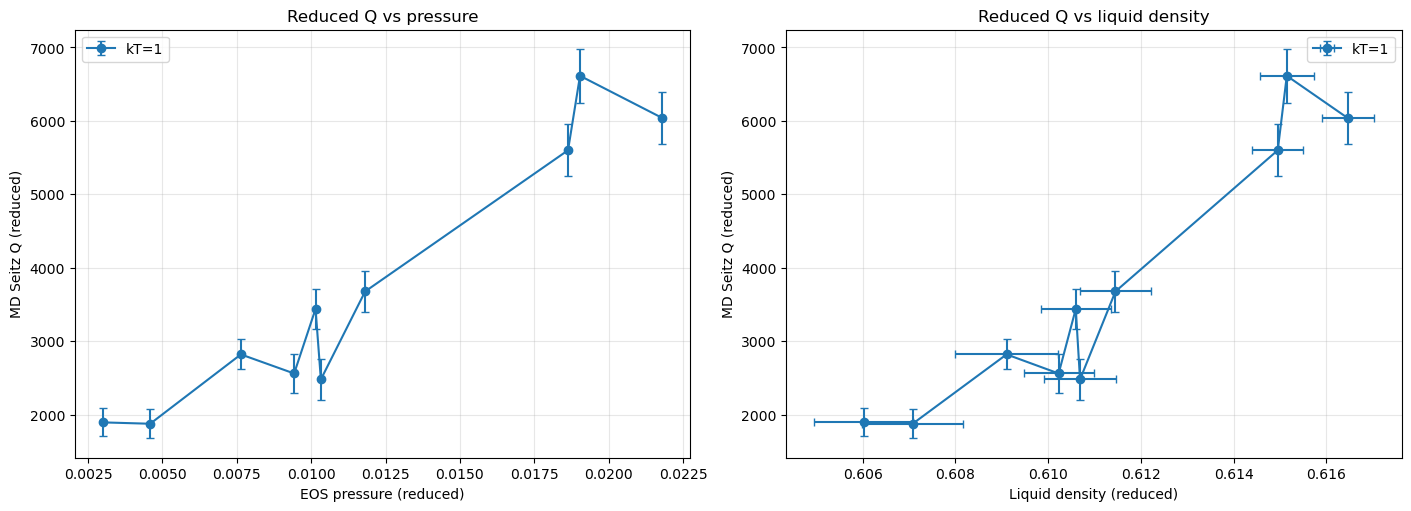

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for temperature, group in results.groupby("Therm_kT"):
    group = group.sort_values("P_EOS")
    axes[0].errorbar(group["P_EOS"], group["Q"], yerr=group["Q_uncertainty"],
                     marker="o", capsize=3, label=f"kT={temperature:g}")
    axes[1].errorbar(group["rho_liquid"], group["Q"],
                     xerr=group["rho_liquid_uncertainty"], yerr=group["Q_uncertainty"],
                     marker="o", capsize=3, label=f"kT={temperature:g}")
axes[0].set(xlabel="EOS pressure (reduced)", ylabel="MD Seitz Q (reduced)", title="Reduced Q vs pressure")
axes[1].set(xlabel="Liquid density (reduced)", ylabel="MD Seitz Q (reduced)", title="Reduced Q vs liquid density")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.3)
plt.show()


## Convert the same states to physical Argon units


In [7]:
results["T_K"] = scale.temperature(results["Therm_kT"])
results["T_C"] = results["T_K"] - 273.15
results["P_bar"] = scale.pressure(results["P_EOS"], "bar")
results["P_psia"] = results["P_bar"] * 14.5037738
results["Q_MD_keV"] = scale.energy(results["Q"], "keV")
results["Q_MD_uncertainty_keV"] = scale.energy_uncertainty(
    results["Q"], results["Q_uncertainty"], "keV"
)
results["rho_liquid_mol_L"] = scale.number_density(results["rho_liquid"], "mol/L")
results["rho_liquid_uncertainty_mol_L"] = scale.number_density_uncertainty(
    results["rho_liquid"], results["rho_liquid_uncertainty"], "mol/L"
)

physical_columns = [
    "Run_ID", "Therm_kT", "T_K", "P_EOS", "P_bar", "P_psia",
    "rho_liquid_mol_L", "Q", "Q_MD_keV", "Q_MD_uncertainty_keV",
]
results[physical_columns]


,Run_ID,Therm_kT,T_K,P_EOS,P_bar,P_psia,rho_liquid_mol_L,Q,Q_MD_keV,Q_MD_uncertainty_keV
0,20260918194755,1.0,128.599551,0.002994,1.403244,20.352328,26.563231,1894.895325,0.020999,0.002130
1,20260918192601,1.0,128.599551,0.004589,2.150527,31.190755,26.609658,1876.272721,0.020793,0.002191
2,20260918192848,1.0,128.599551,0.007637,3.579119,51.910727,26.698414,2820.367009,0.031255,0.002265
3,20260918193606,1.0,128.599551,0.009427,4.418197,64.080524,26.747632,2560.496690,0.028375,0.003013
4,20260918195515,1.0,128.599551,0.010146,4.755320,68.970083,26.763815,3439.574425,0.038117,0.003080
5,20260918195040,1.0,128.599551,0.010325,4.839212,70.186833,26.767843,2479.260405,0.027475,0.003093
6,20260918194043,1.0,128.599551,0.011814,5.536865,80.305436,26.801332,3677.723768,0.040756,0.003125
7,20260918190731,1.0,128.599551,0.018633,8.732729,126.657532,26.954746,5599.897110,0.062057,0.003947
8,20260918191538,1.0,128.599551,0.019035,8.921394,129.393882,26.963282,6613.466495,0.073289,0.004028
9,20260918200708,1.0,128.599551,0.021799,10.216672,148.180302,27.020776,6039.557470,0.066929,0.003979


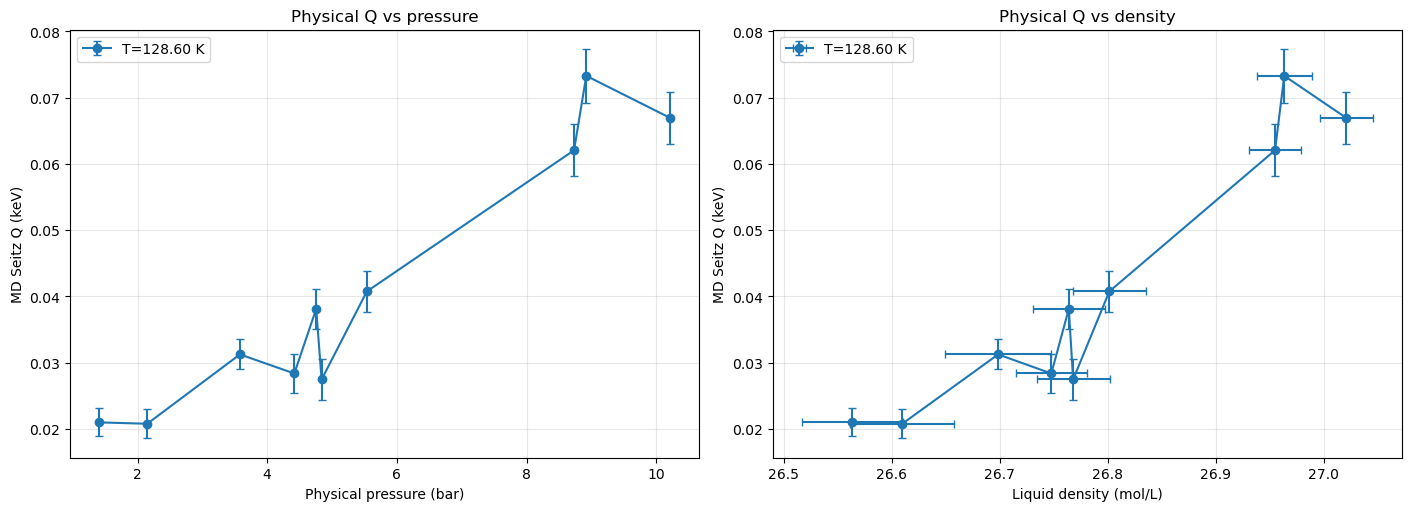

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for temperature, group in results.groupby("T_K"):
    group = group.sort_values("P_bar")
    axes[0].errorbar(group["P_bar"], group["Q_MD_keV"], yerr=group["Q_MD_uncertainty_keV"],
                     marker="o", capsize=3, label=f"T={temperature:.2f} K")
    axes[1].errorbar(group["rho_liquid_mol_L"], group["Q_MD_keV"],
                     xerr=group["rho_liquid_uncertainty_mol_L"],
                     yerr=group["Q_MD_uncertainty_keV"], marker="o", capsize=3,
                     label=f"T={temperature:.2f} K")
axes[0].set(xlabel="Physical pressure (bar)", ylabel="MD Seitz Q (keV)", title="Physical Q vs pressure")
axes[1].set(xlabel="Liquid density (mol/L)", ylabel="MD Seitz Q (keV)", title="Physical Q vs density")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.3)
plt.show()


In [9]:
output_path = DATA_DIRECTORY / "md_seitz_states.csv"
results.to_csv(output_path, index=False)
print("Saved:", output_path)


Saved: /home/pnichols/MDsims/Argon/data/md_seitz_states.csv
